**Clustering Analysis**

This clustering analysis uses the data object that was preprocessed with the following code: https://colab.research.google.com/drive/1T-9tjYt9d0R0qchyXqCCquRLJwz2ZZgb

In [ ]:
# Load the libraries
# from google.colab import drive
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
# drive.mount('/content/drive')
# Load in the data. Note the data was already preprocessed in an earlier step!
df_reduced = pd.read_csv('Titanic-Dataset-reduced.csv')
df_reduced.head()

Mounted at /content/drive


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Title_Master,Title_Miss,Title_Mr,Title_Mrs
0,0,3,22.0,1,0,2.110213,2,False,True,False,False,True,False
1,1,1,38.0,1,0,4.280593,2,True,False,False,False,False,True
2,1,3,26.0,0,0,2.188856,1,True,False,False,True,False,False
3,1,1,35.0,1,0,3.990834,2,True,False,False,False,False,True
4,0,3,35.0,0,0,2.202765,1,False,True,False,False,True,False


In [ ]:
df_reduced.shape #Should be 891 x 13

(891, 13)

Because clustering is an unsupervised learning method, our target variable (`Survived`) was removed from the feature set. The goal is to identify natural groupings based solely on the underlying characteristics of the data, rather than training the model to predict a specific outcome. Excluding this label ensures that the clusters are formed only based on feature similarity.

In [ ]:
# Drop the target variable from the feature set
X = df_reduced.drop(columns=['Survived'])

Because K-Means clustering relies on Euclidean distance, features must be scaled so that variables with larger magnitudes (such as `Fare`) do not disproportionately dominate the results. Although we scaled the data during the initial preprocessing to evaluate feature importance, that step involved the original, full set of features. After dropping low-information columns and returning to the raw dataframe to create a reduced feature set, we did an additional scaling step to ensure the remaining features are normalized. Consistent scaling is necessary for our distance-sensitive clustering algorithms like K-Means, hierarchical clustering, and DBSCAN, as it ensures all features contribute equally to the distance calculations, resulting in more accurate clustering.

In [ ]:
# Get new scaled vals after dropping features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Use the Elbow Method to determine the optimal number of clusters (`k`) for K-means clustering.

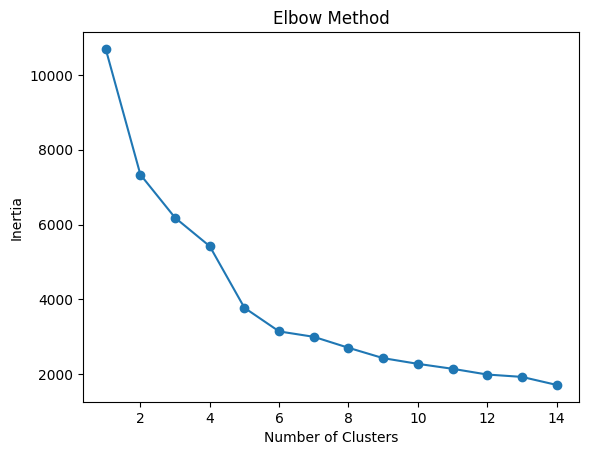

In [ ]:
inertia = []
# calculate the values
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the results
plt.plot(range(1,15), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Looking at the elbow plot, it looks like `k=5` may be an ideal choice because after that point, the decrease slows down significantly.
To help us confirm our decision, we will also calculate the silhouette score, which is helpful to evaluate how well the data has been clustered by measuring both how close points are within a cluster and how distinct each cluster is from others.

In [ ]:
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.406
k=3, silhouette score=0.442
k=4, silhouette score=0.357
k=5, silhouette score=0.432
k=6, silhouette score=0.447
k=7, silhouette score=0.449
k=8, silhouette score=0.445
k=9, silhouette score=0.445
k=10, silhouette score=0.446
k=11, silhouette score=0.430
k=12, silhouette score=0.419
k=13, silhouette score=0.424
k=14, silhouette score=0.434


Based on the silhouette score alone, `k=7` is a strongest choice because it has the highest silhouette score. `k=6` is the second highest option.



Overall, `k=5`, `k=6`, and `k=7` are all reasonable choices based on the silhouette scores and the elbow method. We experimented with each value using the code below to see how the clusters differed in terms of `Fare`, `FamilySize`, and `Pclass`. The distributions all looked similar and reasonable, but we ultimately selected a compromise between the elbow and silhouette results, `k=6`, because it provides a good balance between capturing detailed patterns in the data and maintaining clarity in the clustering results.


**Clustering**

As explained in the above section, we attempted clustering with a variety of `k` values, but we decided that `k=6` provided the best balance of interpretable and clear clusters for the purposes of this analysis.

**Note:** To keep the notebook clear and organized, we are only displaying results for `k=6` in this notebook. To view results for other cluster sizes, simply change the k values at the commented regions

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42) # Set n_clusters to the ideal k size. For this analysis, we chose k=6

# Fit and predict clusters
cluster_labels = kmeans.fit_predict(X_scaled)

# add cluster labels to DF
df_reduced['KMeans_Cluster'] = cluster_labels

In [ ]:
# Reduce to 2 dims so we can visualize
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

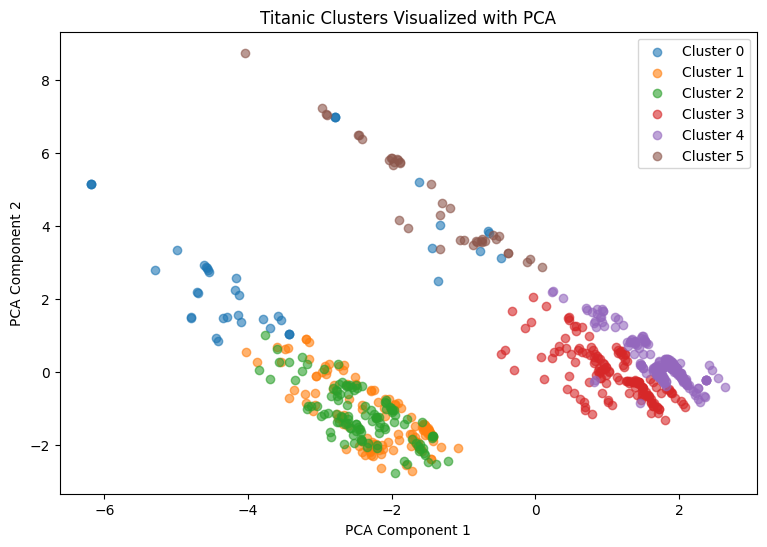

In [ ]:
# visualize the results
plt.figure(figsize=(9,6))
for cluster in range(6):  # Set range for the number of clusters. For now, k=6
    plt.scatter(
        X_pca[cluster_labels == cluster, 0],
        X_pca[cluster_labels == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Titanic Clusters Visualized with PCA')
plt.legend()
plt.show()

As we can see, two large, distinct clusters are immediately evident, with `clusters 3`, `4`, and `5` grouped together and `clusters 0`, `1`, and `2` forming another group. The exception is that `cluster 0 `appears somewhat split between the two groups. This separation is likely driven by `Sex_male` and `Sex_female`, which had the highest impact on survival rates. We can also observe subclusters within each gender group. Further analysis of these populations will be conducted below based on their mean values.

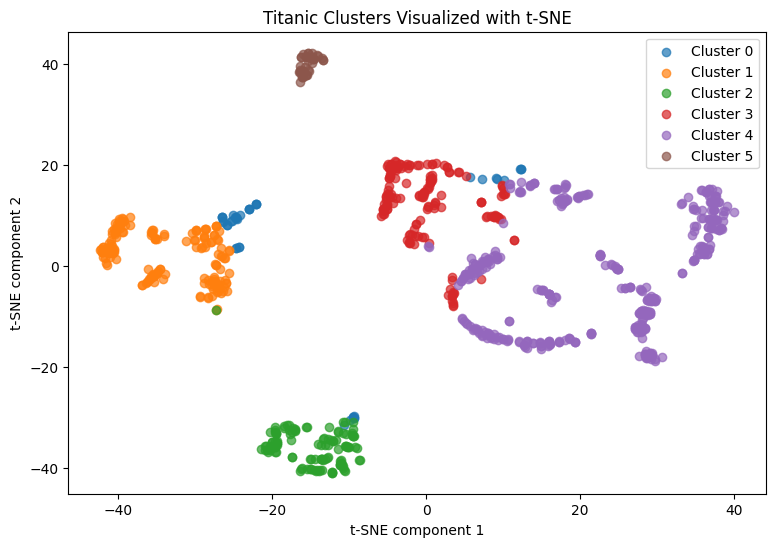

In [ ]:
# Run TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)


# label the clusters
plt.figure(figsize=(9,6))
for cluster in range(6):  # Set range to number of clsuters. For now, k=6 clusters
    plt.scatter(
        X_tsne[cluster_labels == cluster, 0],
        X_tsne[cluster_labels == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.title('Titanic Clusters Visualized with t-SNE')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend()
plt.show()

We also look at the plot for t-SNE to reduce high-dimensional data to two or three dimensions while preserving the local structure, making clusters easier to visualize. Compared to PCA, t-SNE often provides greater separation between groups, allowing patterns and potential outliers to be more clearly identified. We can still see that `cluster 3` and `cluster 4` are closer to one another, but `cluster 1` and `cluster 2` have more separation.

In [ ]:
# added formatting for these to make it easier to read
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

cluster_summary = (
    df_reduced
    .groupby('KMeans_Cluster')[ ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
         'Sex_female', 'Sex_male', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs']]
    .describe()
    .round(2)
    .transpose()
)

# print with spacing between features
features = cluster_summary.index.get_level_values(0).unique()
for i, feature in enumerate(features):
    print(feature)
    print(cluster_summary.loc[feature])
    if i < len(features) - 1:
        print("\n") # Add a newline for spacing

pd.reset_option('display.width')
pd.reset_option('display.max_columns')

Survived
KMeans_Cluster     0       1       2       3       4      5
count           41.0  164.00  120.00  156.00  370.00  40.00
mean             0.2    0.77    0.82    0.28    0.11   0.57
std              0.4    0.42    0.38    0.45    0.32   0.50
min              0.0    0.00    0.00    0.00    0.00   0.00
25%              0.0    1.00    1.00    0.00    0.00   0.00
50%              0.0    1.00    1.00    0.00    0.00   1.00
75%              0.0    1.00    1.00    1.00    0.00   1.00
max              1.0    1.00    1.00    1.00    1.00   1.00


Pclass
KMeans_Cluster      0       1       2       3       4      5
count           41.00  164.00  120.00  156.00  370.00  40.00
mean             2.68    2.23    1.93    1.28    2.82   2.62
std              0.72    0.86    0.82    0.45    0.42   0.63
min              1.00    1.00    1.00    1.00    1.00   1.00
25%              3.00    1.00    1.00    1.00    3.00   2.00
50%              3.00    3.00    2.00    1.00    3.00   3.00
75%            

Examine the categorical features

In [ ]:
# Look at the categorical titles
categorical_cols = ['Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs'] #'Sex_male', 'Sex_female',
cluster_props = df_reduced.groupby('KMeans_Cluster')[categorical_cols].mean()

# Convert to percentages
cluster_props_pct = cluster_props.copy()
for col in cluster_props_pct.columns:
    cluster_props_pct[col] = cluster_props_pct[col].map(lambda x: f"{x*100:.1f}%")

print(cluster_props_pct)

               Title_Master Title_Miss Title_Mr Title_Mrs
KMeans_Cluster                                           
0                      0.0%      56.1%    26.8%     17.1%
1                      0.0%      98.8%     0.0%      0.0%
2                      0.0%       0.0%     0.0%     99.2%
3                      0.0%       0.0%    89.1%      0.0%
4                      0.0%       0.0%    99.2%      0.0%
5                    100.0%       0.0%     0.0%      0.0%


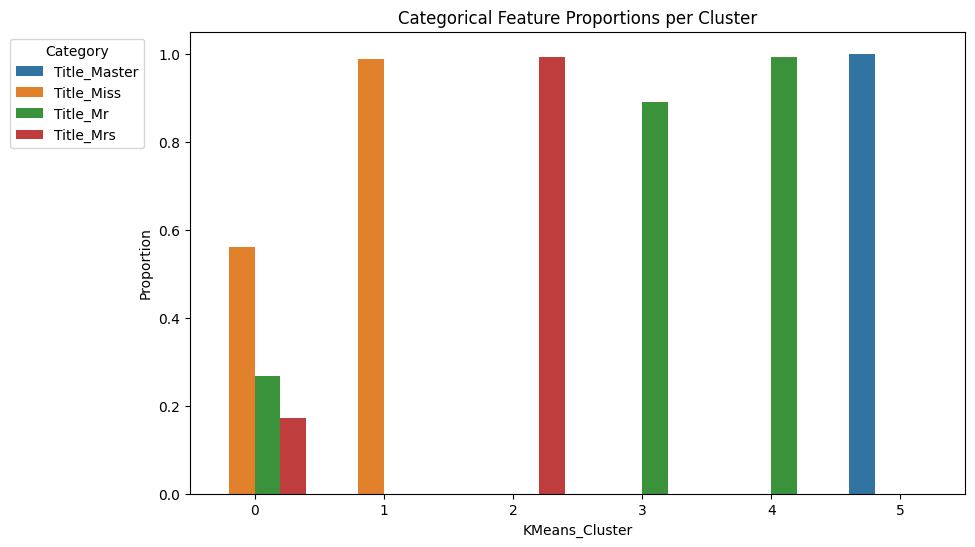

In [ ]:
# Plot the vals from above
cluster_categorical_long= cluster_props.reset_index().melt(id_vars='KMeans_Cluster',
                                                      var_name='Category',
                                                      value_name='Proportion')

plt.figure(figsize=(10, 6))
sns.barplot(x='KMeans_Cluster', y='Proportion', hue='Category', data=cluster_categorical_long)
plt.title('Categorical Feature Proportions per Cluster')
plt.ylabel('Proportion')
plt.xlabel('KMeans_Cluster')
plt.legend(title='Category', bbox_to_anchor=(-0.05, 1), loc='upper right')
plt.show()

As we can see, there is not a lot of variety within the clusters in terms of the genders and ages. With the exception of `cluster 0`, the other clusters appear to be discriminated partially by `title`, because they are dominated by a single `title`. For instance, `cluster 5`, is exclusively people labeled `Title_Master`, which means that that the cluster only consists of young boys.



KMeans_Cluster
0    0.195122
1    0.768293
2    0.825000
3    0.282051
4    0.113514
5    0.575000
Name: Survived, dtype: float64


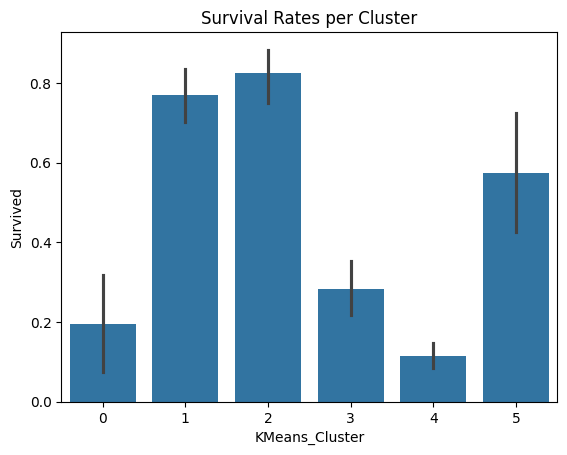

In [ ]:
# Check how survival rates vary by cluster
survival_by_cluster = df_reduced.groupby('KMeans_Cluster')['Survived'].mean()
print(survival_by_cluster)

sns.barplot(x='KMeans_Cluster', y='Survived', data=df_reduced)
plt.title("Survival Rates per Cluster")
plt.show()

As we can see, there is a high amount of variation betwen the clsuters. Clusters 1 and 2 have a relatively high survival rate, while clusters 4, 3, and 0 have a very low survival rate. Cluster 5 is in between.

**Detailed Interpretation of Clusters**

**Cluster 0:** This cluster represents large families with low `survival` rates. The mean survival is only 20%, which is the second-lowest among all clusters. Passengers are relatively young (mean `age` ~23) and come from second and third class (mean `Pclass` 2.68). They have the largest families, with an average `FamilySize` of 6.85, and many siblings/spouses (mean `SibSp` 3.37) and parents/children (mean `Parch` 2.49). The `Fare`s are moderate-high in log-transformed units (mean 3.86), meaning the number is not the raw fare but can be used to compare clusters relatively. This cluster is mixed in terms of passenger titles: 56.1% `Title_Miss` (unmarried women or girls), 26.8% `Title_Mr` (adult men), and 17.1% `Title_Mrs` (married women). Likely contains extended families traveling together, which may have contributed to lower survival due to crowding or slower evacuation.

**Cluster 1:** This cluster represents younger female passengers with high `survival` (mean 77%). They are mostly `Title_Miss` (98.8%), indicating unmarried women or girls, with small families (`FamilySize` 1.62) and very few siblings or parents onboard. Passengers are slightly older than Cluster 0 (mean `age` ~24), mostly second-class (mean `Pclass` 2.23), and `Fare`s are moderate in log-transformed units (mean 3.10). Being in second-class cabins, likely on higher decks, may have further improved their chances during evacuation.

**Cluster 2:** This cluster has the highest `survival` rate at 82% and represents older female passengers in first class (99.2% `Title_Mrs`). `FamilySize` is small (2.28), `SibSp` and `Parch` are low (0.68 and 0.59), and `Fare`s are relatively high in log-transformed units (mean 3.48). This cluster likely captures wealthier married women in first-class cabins who were prioritized during evacuation.

**Cluster 3:** This cluster represents adult male passengers with low-to-moderate `survival` (28%). Most are `Title_Mr` (89.1%), with small families (`FamilySize` 1.59), relatively high `Fare`s in log-transformed units (3.72), and are among the oldest passengers (mean `age` ~40). They are mostly first-class (mean `Pclass` 1.28). This cluster likely contains older men traveling alone or with small families, which may explain the lower survival compared to Cluster 2 despite high class.

**Cluster 4:** This cluster represents low-survival third-class passengers (mean `survival` 11%). Almost all are adult men (`Title_Mr` 99.2%), moderately young (mean `age` ~28.5), and travel in very small families or alone (`FamilySize` 1.20). `Fare`s are the lowest among clusters in log-transformed units (mean 2.27). This cluster likely captures poorly situated third-class men, historically located on lower decks with limited access to lifeboats, explaining the very low survival rate.

**Cluster 5:** This cluster represents young boys (`Title_Master` 100%) with moderate `survival` (57%). The mean `age` is very low (~7 years), and `FamilySize` is larger than other small clusters (mean 4.68), indicating multiple siblings/parents onboard. `Pclass` is mostly second class (mean 2.62), and `Fare`s are moderate in log-transformed units (mean 3.38). This cluster likely captures young male children traveling with families, who benefited from "women and children first" evacuation policies.

**Hierarchical Clustering Method**

An addition to K-Means, we want to try another clustering method called hierarchical clustering. K-means assigns points into a fixed number of clusters by minimizing distance to cluster centers, so you have to choose the number of clusters upfront. In contrast, Hierarchical clustering groups data by progressively merging the closest points into a tree-like structure (see dendrogram output below), showing how clusters form at different levels. Because of this, it lets you see the natural grouping structure first and decide how many clusters make sense based on the data.

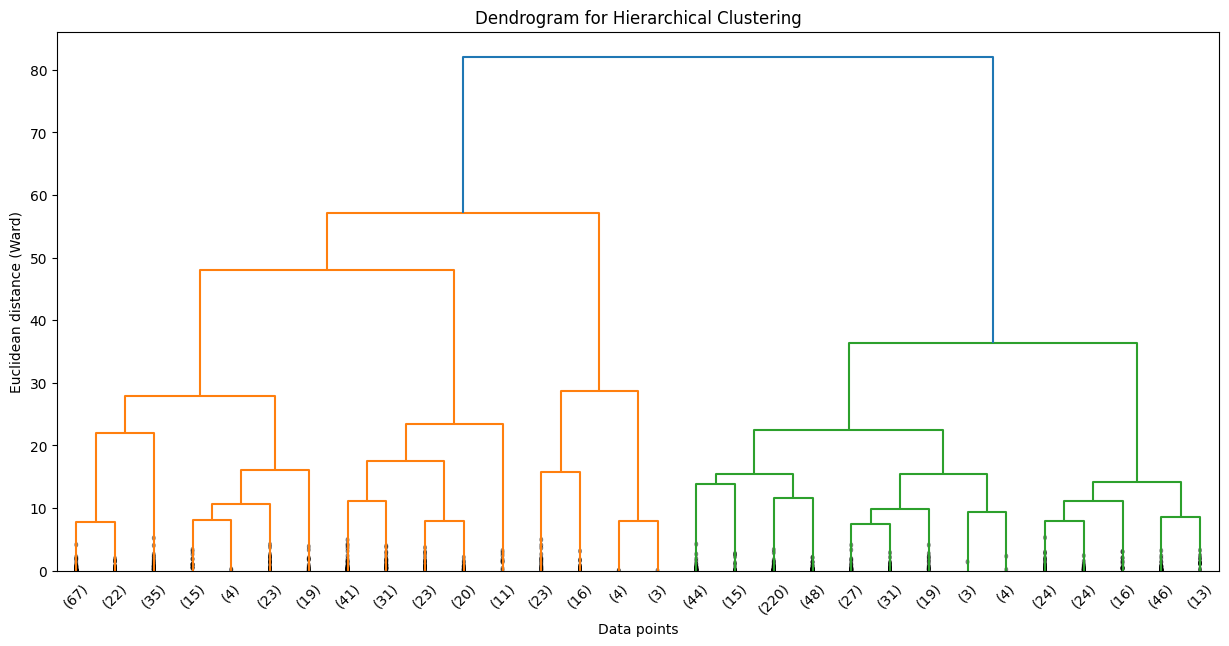

In [ ]:
# perform hierarchical clustering (initial run for dendrogram)
# for the dendrogram, we don't need to specify n_clusters yet.
linked = sch.linkage(X_scaled, method='ward')

# visualize dendrogram
plt.figure(figsize=(15, 7))
sch.dendrogram(linked,
               orientation='top',
               truncate_mode='lastp',  # show only the last 'p' merged clusters
               p=30,                    # display 30 leaf nodes
               show_leaf_counts=True,
               distance_sort='descending',
               show_contracted=True)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data points')
plt.ylabel('Euclidean distance (Ward)')
plt.show()

Above is the dendrogram resulting from hierarchical clustering. The number of clusters can be chosen by examining the vertical distances at which clusters merge. While there is a large vertical jump when selecting only 2 clusters, which might suggest a natural division, these two clusters would likely correspond simply to men and women, which is overly simplistic. To capture more nuance in the data, we consider other points with significant vertical jumps. Based on this, selecting 4 clusters appears to be a reasonable choice, balancing interpretability and meaningful subgroup structure.

In [ ]:
# assign hierarchical cluster labels
# based on the dendrogram i will choose 4 clusters to start
n_hierarchical_clusters = 4 # can adjust this based on dendrogram
hc = AgglomerativeClustering(n_clusters=n_hierarchical_clusters, metric='euclidean', linkage='ward')
hierarchical_cluster_labels = hc.fit_predict(X_scaled)

# add hierarchical cluster labels to df_reduced
df_reduced['Hierarchical_Cluster'] = hierarchical_cluster_labels

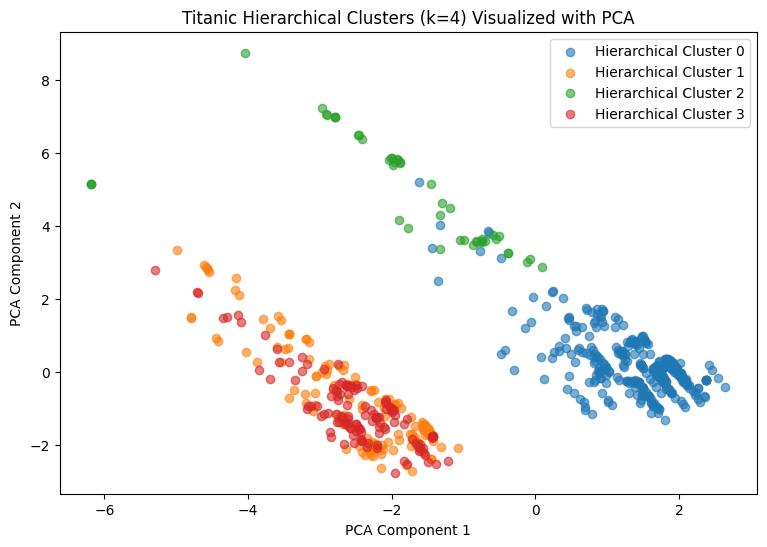

In [ ]:
# visualization with PCA
plt.figure(figsize=(9, 6))
for cluster in range(n_hierarchical_clusters):
    plt.scatter(
        X_pca[hierarchical_cluster_labels == cluster, 0],
        X_pca[hierarchical_cluster_labels == cluster, 1],
        label=f'Hierarchical Cluster {cluster}',
        alpha=0.6
    )
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Titanic Hierarchical Clusters (k={n_hierarchical_clusters}) Visualized with PCA')
plt.legend()
plt.show()

Just like our PCA visualization for K-Means, hierarchical clustering produces 2 very distinct larger clusters. Clusters `0` and `2` group together, and clusters `1` and `3` group together. This is mostly likely seprating the men and the women.

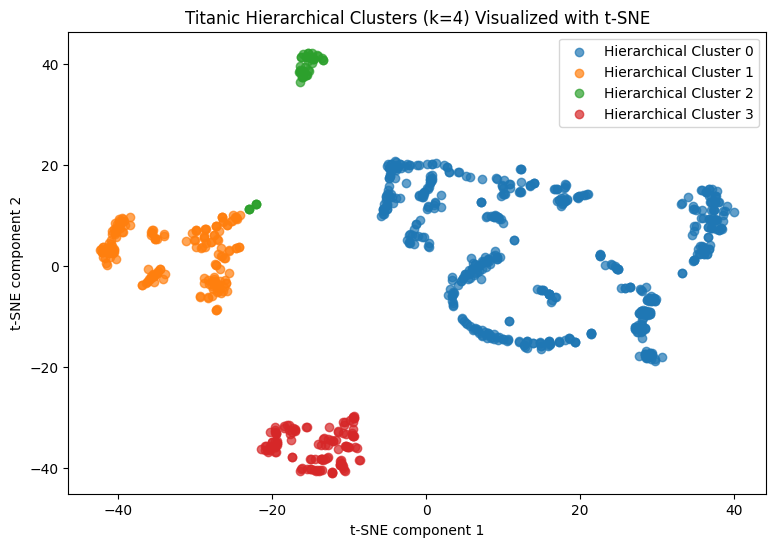

In [ ]:
# visualization with t-SNE
plt.figure(figsize=(9, 6))
for cluster in range(n_hierarchical_clusters):
    plt.scatter(
        X_tsne[hierarchical_cluster_labels == cluster, 0],
        X_tsne[hierarchical_cluster_labels == cluster, 1],
        label=f'Hierarchical Cluster {cluster}',
        alpha=0.7
    )
plt.title(f'Titanic Hierarchical Clusters (k={n_hierarchical_clusters}) Visualized with t-SNE')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend()
plt.show()

The TSNE viusalization shows a clear separation between the 4 clusters, producing very distinct groups. Cluster `0` is the most spread out, and clusters` 2` and `3` are quite compact.

In [ ]:
# added new formatting for these to make it easier to read
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

hierarchical_cluster_summary = (
    df_reduced
    .groupby('Hierarchical_Cluster')[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
         'Sex_female', 'Sex_male', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs']] #['Fare','FamilySize','Pclass']
    .describe()
    .round(2)
    .transpose()
)

# Print with spacing between features
features = hierarchical_cluster_summary.index.get_level_values(0).unique()
for i, feature in enumerate(features):
    print(feature)
    print(hierarchical_cluster_summary.loc[feature])
    if i < len(features) - 1:
        print("\n") # Add a newline for spacing

pd.reset_option('display.width')
pd.reset_option('display.max_columns')

Survived
Hierarchical_Cluster       0       1      2       3
count                 534.00  185.00  46.00  126.00
mean                    0.16    0.72   0.50    0.79
std                     0.37    0.45   0.51    0.41
min                     0.00    0.00   0.00    0.00
25%                     0.00    0.00   0.00    1.00
50%                     0.00    1.00   0.50    1.00
75%                     0.00    1.00   1.00    1.00
max                     1.00    1.00   1.00    1.00


Pclass
Hierarchical_Cluster       0       1      2       3
count                 534.00  185.00  46.00  126.00
mean                    2.37    2.26   2.67    1.99
std                     0.82    0.86   0.60    0.82
min                     1.00    1.00   1.00    1.00
25%                     2.00    1.00   2.25    1.00
50%                     3.00    3.00   3.00    2.00
75%                     3.00    3.00   3.00    3.00
max                     3.00    3.00   3.00    3.00


Age
Hierarchical_Cluster       0       1    

To understand these results better, we will also visualize some of them below. The interpretation will be at the bottom of the visualizations.

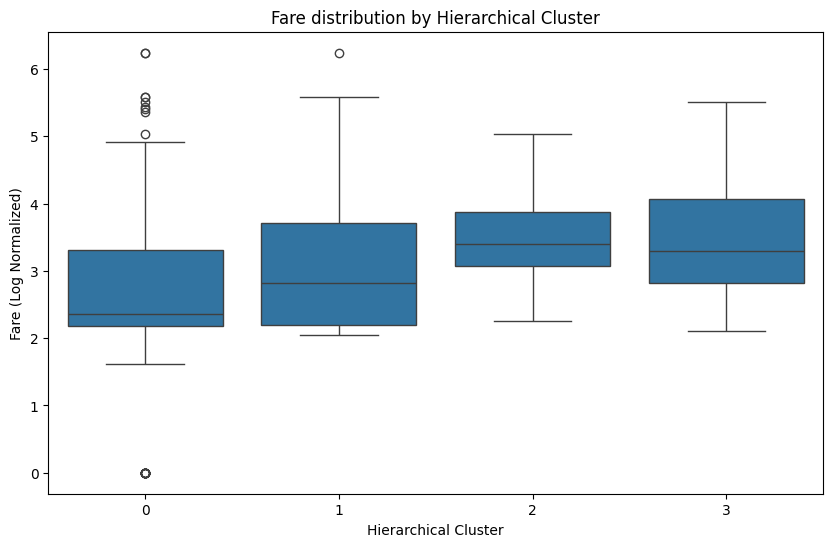

In [ ]:
# plot hierarchical cluster fare distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hierarchical_Cluster', y='Fare', data=df_reduced)
plt.title('Fare distribution by Hierarchical Cluster')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('Fare (Log Normalized)')
plt.show()

According to the log normalized distribution, cluster 0 has the cheapest fares, followed by cluster 1. Clusters 2 and 3 have higher fairs.


Hierarchical Cluster Categorical Feature Proportions:
                       Title_Master  Title_Miss  Title_Mr  Title_Mrs
Hierarchical_Cluster                                               
0                         0.000000    0.000000  0.962547        0.0
1                         0.000000    0.983784  0.000000        0.0
2                         0.869565    0.065217  0.065217        0.0
3                         0.000000    0.000000  0.000000        1.0


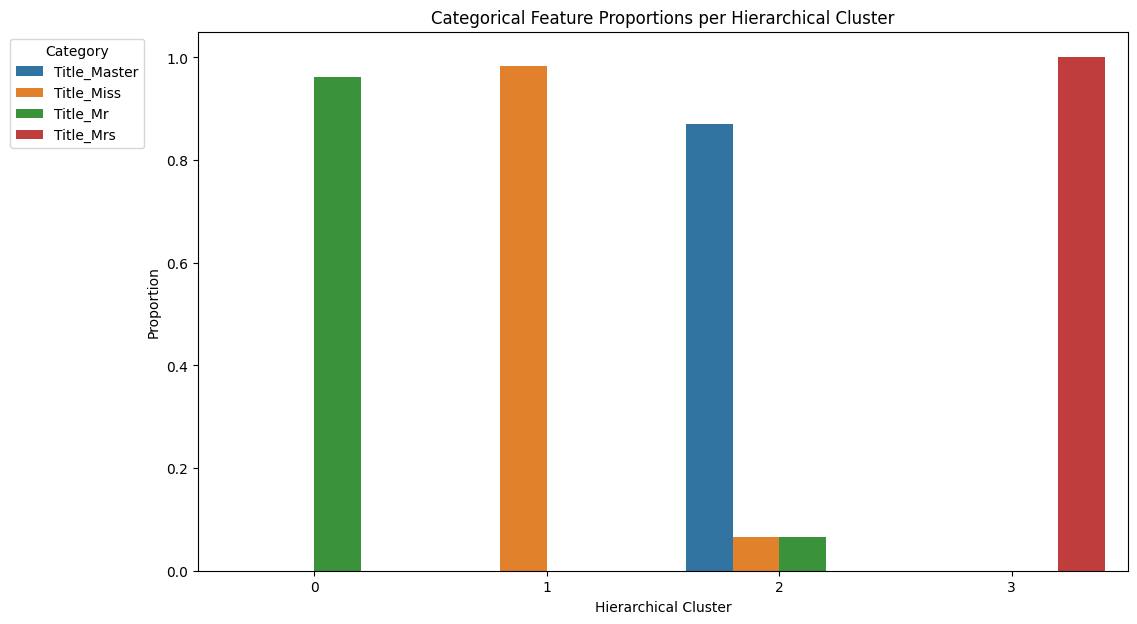

In [ ]:
# analyze hierarchical categorical feature proportions
hierarchical_categorical_props = df_reduced.groupby('Hierarchical_Cluster')[categorical_cols].mean()
print("\nHierarchical Cluster Categorical Feature Proportions:\n", hierarchical_categorical_props)

# plot hierarchical categorical feature proportions
hierarchical_categorical_long = hierarchical_categorical_props.reset_index().melt(id_vars='Hierarchical_Cluster',
                                                                                 var_name='Category',
                                                                                 value_name='Proportion')

plt.figure(figsize=(12, 7))
sns.barplot(x='Hierarchical_Cluster', y='Proportion', hue='Category', data=hierarchical_categorical_long)
plt.title('Categorical Feature Proportions per Hierarchical Cluster')
plt.ylabel('Proportion')
plt.xlabel('Hierarchical Cluster')
plt.legend(title='Category', bbox_to_anchor=(-0.05, 1), loc='upper right')
plt.show()

Again, the clusters have very little diversity in `title` within a cluster. This shows that these features dominate in terms of distinguishing clusters.

Another  way to visualize the proportion with each cluster is with a pie chart.

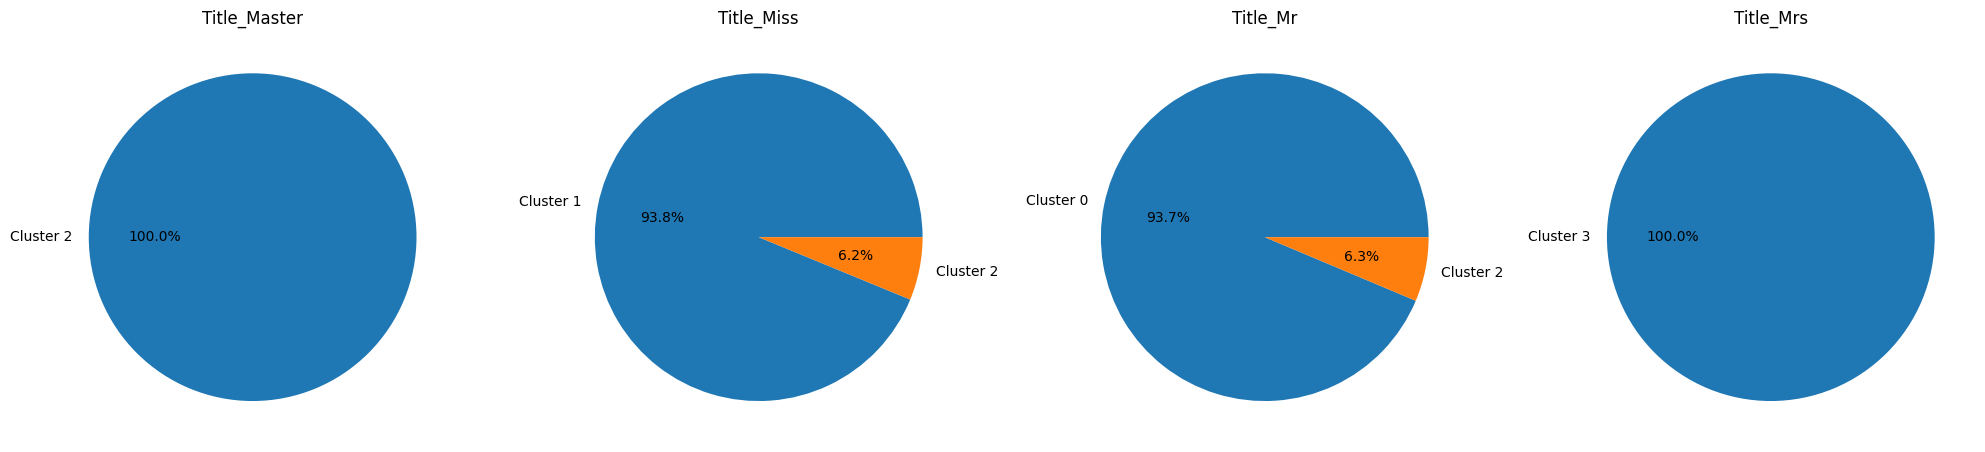

In [ ]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5 * len(categorical_cols), 5))

# handle case where there's only 1 category
if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    values = hierarchical_categorical_props[col]

    # filter out clusters with 0 proportion
    values = values[values > 0]

    # handle edge case: all zeros
    if values.empty:
        axes[i].set_title(f"{col}\n(No data)")
        axes[i].axis('off')
        continue

    axes[i].pie(
        values,
        labels=[f"Cluster {idx}" for idx in values.index],   # match filtered values
        autopct='%1.1f%%'
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Again, this confirms that these are a dominating factor in the cluster assignment.


Hierarchical Cluster Survival Rates:
 Hierarchical_Cluster
0    0.161049
1    0.718919
2    0.500000
3    0.793651
Name: Survived, dtype: float64


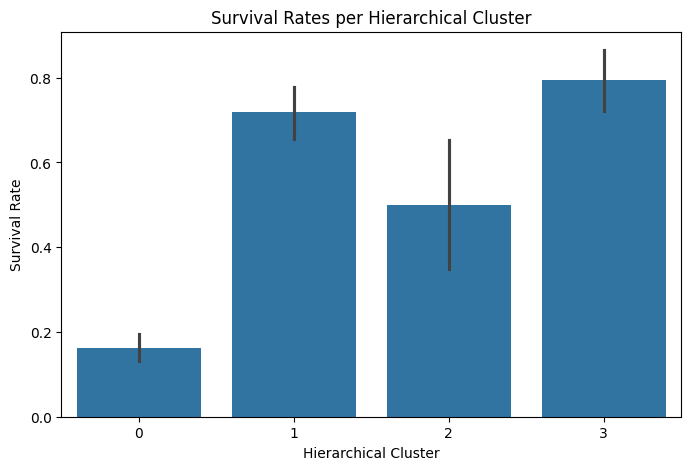

In [ ]:
# calculate hierarchical cluster survival rates
hierarchical_survival_by_cluster = df_reduced.groupby('Hierarchical_Cluster')['Survived'].mean()
print("\nHierarchical Cluster Survival Rates:\n", hierarchical_survival_by_cluster)

# plot hierarchical cluster survival rates
plt.figure(figsize=(8, 5))
sns.barplot(x='Hierarchical_Cluster', y='Survived', data=df_reduced)
plt.title("Survival Rates per Hierarchical Cluster")
plt.xlabel('Hierarchical Cluster')
plt.ylabel('Survival Rate')
plt.show()

As we can see, cluster 0 by far has the worse survival rate. Cluster 3 has the highest.

## Summary:

*   **Hierarchical Cluster Characteristics (k=4):**
    *   **Cluster 0 (Lower-Class, Low Survival Males):** This cluster contains mostly males with the `Title_Master` feature. This was the largest cluster with 534 passengers and a low survival rate of only 16%. Mostly contains 3rd class individuals (median = 3) and an average age of 32, meaning it consists mostly of adults. The family size is ~1.4 so we can assume that most of these individuals traveled alone. And they had the lowest fare overall. This cluster represents working-class adults mostly traveling alone, likely men in third class.
    *   **Cluster 1 (Young Women/Small Families):** This cluster contains majority females almost entirely made up of `Title_Miss`. This group has a fairly high survival rate of 72%. Their average age is 23 (young) and an average family size of ~2 meaning they are likely single mothers. The class level is mixed, but leans towards 2nd and 3rd class. The fare level is moderate so overall, this cluster represents the young women (many unmarried) traveling with small families.
    *   **Cluster 2 (Large Families with Children):** This is the smallest cluster with only 46 passengers. This contains a mixture of titles including `Title_Master` at ~87%, `Title _Miss` at 6.5% and `Title_Mrs` at 6.5%. The survival rate is only 50% indicating a likely mixture of genders. The average age is low at ~9.7 which indicates that there is a substantial amount of children in the cluster. The feature `SibSp` has an average value of 3.04 meaning that there are many siblings. The `Parch` feature has an average value of 1.46 indicating that there are presents in the cluster. The survival rate being mized at 50% grants that insight that the survival advantage of children is partially offset by the logistical challenges of large families and the low survival rate of men.
    *   **Cluster 3 (Wealthier Adults/Families):** This cluster has the highest survival rate (~79%) with a mean class level of ~2 (many 1st class). They also have the highest fare indicating that they are the wealthiest group. Their average age is ~35 and the family size is ~2.5. This cluster is composed primarily of people with the title `Title_Mrs` which reveals that this was composed of married women and their children. Overall, this cluster represets wealthier passengers (mostly women & families) in better cabin locations.
*   **Fare and Class Distribution:** The boxplot of Fare distribution across hierarchical clusters indicates that Clusters 2 and 3 (primarily female clusters with families) tend to have higher median fares and a wider spread, suggesting a higher class composition compared to Clusters 0 and 1. Survival rates increase consistently with fare, supporting the conclusion that wealth and class played a significant role in survival outcomes.

Overall, the hierarchical clustering model identified four distinct passenger profiles that align closely with known survival patterns of the Titanic sinking. Low-survival clusters consisted primarily of lower-class individuals traveling alone, while high-survival clusters were made up of wealthier passengers and smaller family groups. A particularly notable cluster (cluster 2) captured large families with children, revealing a nuanced trade-off where the survival advantage of youth was offset by the challenges of evacuating larger groups and men. Overall, the clustering results highlight the combined influence of socioeconomic status, age, and family structure on survival outcomes.


## DBSCAN

In addition to K-means and hierarchical clustering, we also used DBSCAN to cluster the data. DBSCAN finds clusters based on density, can handle irregularly shaped groups, and automatically flags outliers as noise. This lets us see patterns and groupings that the other methods might miss.


Note: DBScan requires scaling. Instead of reusing the previously scaled X_scaled, I rescaled just to be safe in case X_scaled was changed at all during the colab.

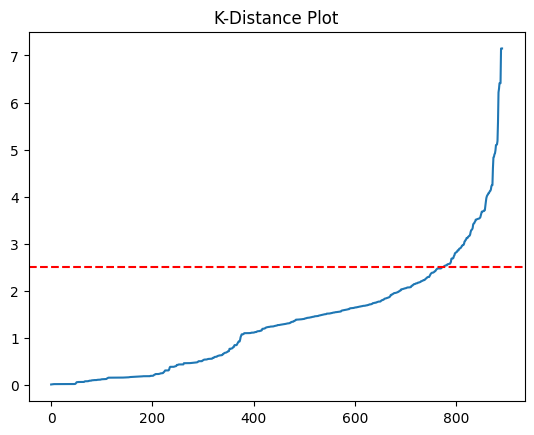

In [ ]:
# Scale again, just to ensure the data is properly scaled for DBScan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine epsilon neighborhood using k=24 -> we can use the elbow plot to determine eps
k = 24 # rule of thumb is to base this value off of 2 x # of features
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1])

# Plot to find Elbow
plt.plot(k_distances)
plt.axhline(y=2.5, color='r', linestyle='--') # Plot line where probable elbow is
plt.title("K-Distance Plot")
plt.show()

### Note: Something that may change the outcome of DBScan is to change the proposed elbow. We could, for example, elect an elbow that is much smaller
### or larger which could effect the outcome of our clustering.

# Cluster
# Use the eps value discovered in the plot above
dbscan = DBSCAN(eps=2.5, min_samples=k) ### the eps value is a parameter we could change based on the result of the elbow plot
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels back to df_reduced
df_reduced['DBScan_Cluster'] = clusters

This K-distance plot shows a gradual increase in distances for most points, followed by a sharp upward bend (elbow) around ~2.5. This suggests that most data points lie in relatively dense regions (distances below ~2.5), while points beyond this threshold are much farther from their neighbors and likely represent noise or outliers.

Choosing `ε ≈ 2.5` is reasonable because it captures the transition between dense clusters and sparse regions, allowing DBSCAN to group the main structure of the data while labeling the more isolated points as noise.

Visualize with PCA

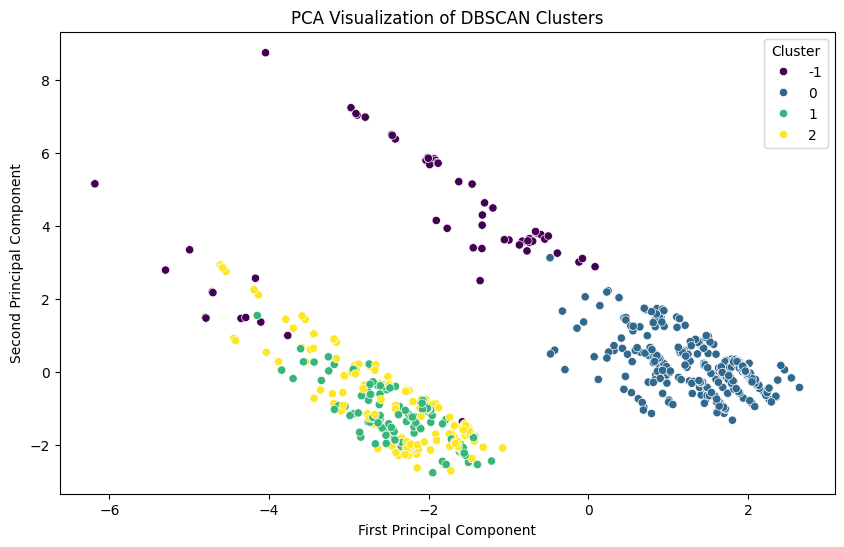

In [ ]:
# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', marker='o')
plt.title("PCA Visualization of DBSCAN Clusters")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend(title='Cluster')
plt.show()

**Note:** values denoted as cluster -1 mean that they are predicted as "noise"/ outliers, and they are values that do not fall into a cluster.

Confirming the patterns of the previous two analysis, we also have two larger distinct groups, separating the men and women.

Visualize with t-sne

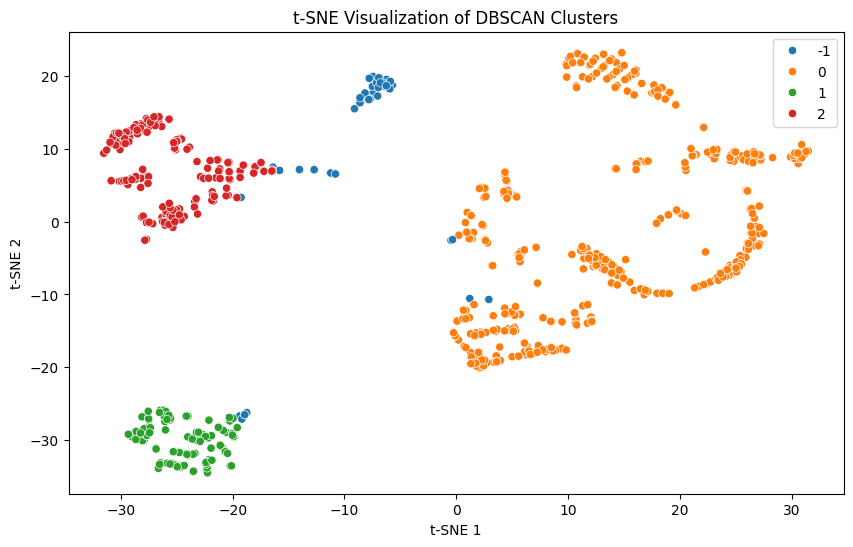

In [ ]:
# Reduce to 2 dimensions
### Perplexity is a hyperparameter that I found is usually between 5 and 50. We can change this to change the outcome of our clustering, I found a higher perplexity maybe does a better job (the clusters are tighter)
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=clusters, palette='tab10', legend='full')
plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

**Note:** values denoted as cluster -1 mean that they are predicted as "noise" values that do not fall into a cluster.

Again, we see a very clear separation between the clusters

In [ ]:
# Print head of the new df with new clusters from dbscan
df_reduced.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_female,Sex_male,Title_Master,Title_Miss,Title_Mr,Title_Mrs,KMeans_Cluster,Hierarchical_Cluster,DBScan_Cluster
0,0,3,22.0,1,0,2.110213,2,False,True,False,False,True,False,4,0,0
1,1,1,38.0,1,0,4.280593,2,True,False,False,False,False,True,2,3,1
2,1,3,26.0,0,0,2.188856,1,True,False,False,True,False,False,1,1,2
3,1,1,35.0,1,0,3.990834,2,True,False,False,False,False,True,2,3,1
4,0,3,35.0,0,0,2.202765,1,False,True,False,False,True,False,4,0,0


## DBSCAN Cluster Analysis

In [ ]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

dbscan_cluster_summary = (
    df_reduced
    .groupby('DBScan_Cluster')[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
         'Sex_female', 'Sex_male', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs']]
    .describe()
    .round(2)
    .transpose()
)

print("DBSCAN Cluster Numerical Feature Summary:\n", dbscan_cluster_summary)

# Print with spacing between features
features = dbscan_cluster_summary.index.get_level_values(0).unique()
for i, feature in enumerate(features):
    print(feature)
    print(dbscan_cluster_summary.loc[feature])
    if i < len(features) - 1:
        print("\n") # Add a newline for spacing

pd.reset_option('display.width')
pd.reset_option('display.max_columns')


DBSCAN Cluster Numerical Feature Summary:
 DBScan_Cluster       -1       0       1       2
Survived   count  65.00  527.00  119.00  180.00
           mean    0.43    0.16    0.83    0.72
           std     0.50    0.37    0.38    0.45
           min     0.00    0.00    0.00    0.00
           25%     0.00    0.00    1.00    0.00
           50%     0.00    0.00    1.00    1.00
           75%     1.00    0.00    1.00    1.00
           max     1.00    1.00    1.00    1.00
Pclass     count  65.00  527.00  119.00  180.00
           mean    2.62    2.37    1.93    2.27
           std     0.70    0.82    0.81    0.86
           min     1.00    1.00    1.00    1.00
           25%     2.00    2.00    1.00    1.00
           50%     3.00    3.00    2.00    3.00
           75%     3.00    3.00    3.00    3.00
           max     3.00    3.00    3.00    3.00
Age        count  65.00  527.00  119.00  180.00
           mean   16.19   31.93   34.48   23.23
           std    15.34   11.56   11.17   12.

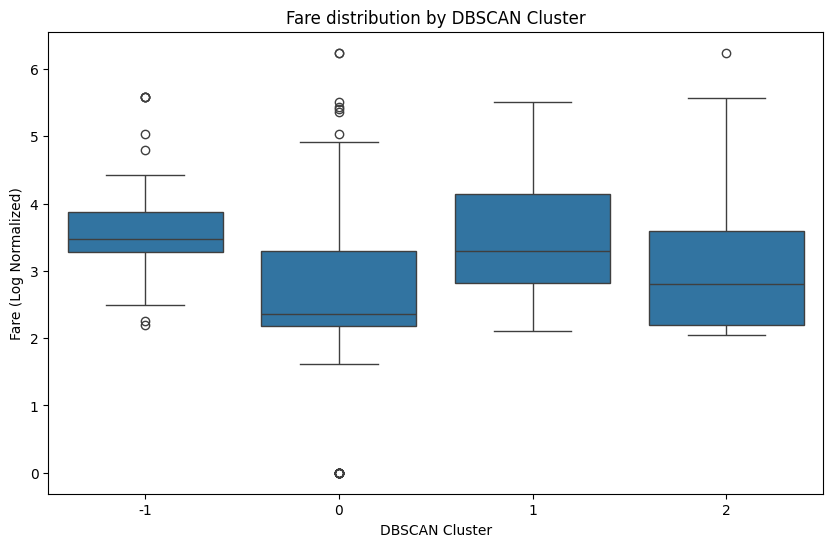

In [ ]:
# plot DBSCAN cluster fare distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='DBScan_Cluster', y='Fare', data=df_reduced)
plt.title('Fare distribution by DBSCAN Cluster')
plt.xlabel('DBSCAN Cluster')
plt.ylabel('Fare (Log Normalized)')
plt.show()


As we can see above, on average, Cluster 0 has the lowest fare, while cluster 1 has the highest fare


DBSCAN Cluster Categorical Feature Proportions:
                 Title_Master  Title_Miss  Title_Mr  Title_Mrs
DBScan_Cluster                                               
-1                  0.615385    0.107692  0.153846   0.107692
 0                  0.000000    0.000000  0.962049   0.000000
 1                  0.000000    0.000000  0.000000   1.000000
 2                  0.000000    0.988889  0.000000   0.000000


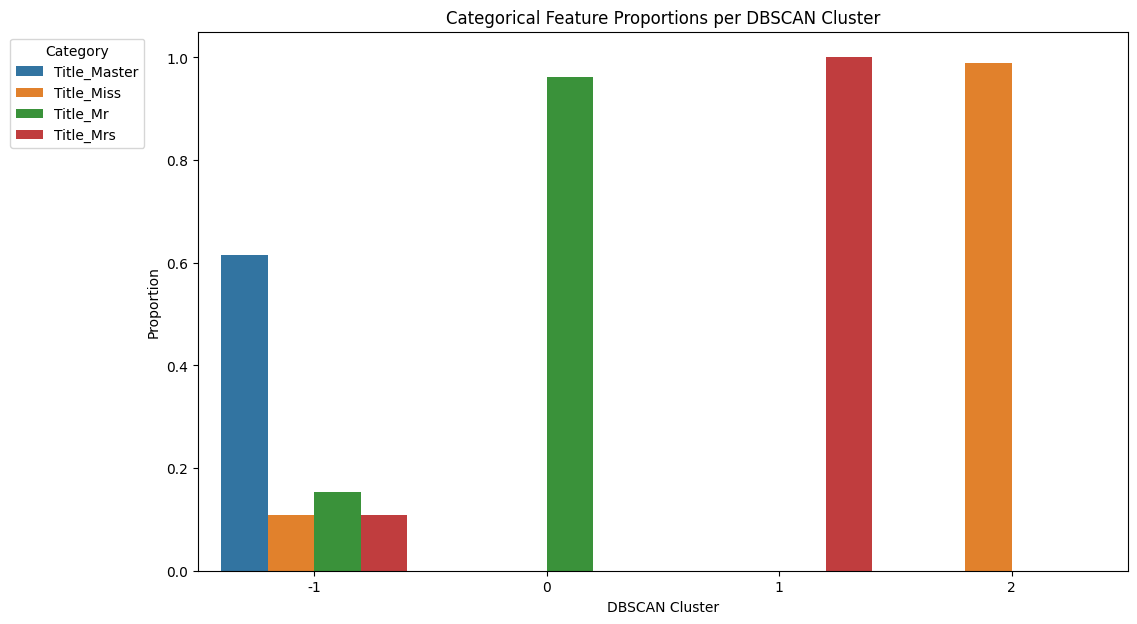

In [ ]:
# analyze DBSCAN categorical feature proportions
dbscan_categorical_props = df_reduced.groupby('DBScan_Cluster')[categorical_cols].mean()
print("\nDBSCAN Cluster Categorical Feature Proportions:\n", dbscan_categorical_props)

# plot DBSCAN categorical feature proportions
dbscan_categorical_long = dbscan_categorical_props.reset_index().melt(id_vars='DBScan_Cluster',
                                                                                 var_name='Category',
                                                                                 value_name='Proportion')

plt.figure(figsize=(12, 7))
sns.barplot(x='DBScan_Cluster', y='Proportion', hue='Category', data=dbscan_categorical_long)
plt.title('Categorical Feature Proportions per DBSCAN Cluster')
plt.ylabel('Proportion')
plt.xlabel('DBSCAN Cluster')
plt.legend(title='Category', bbox_to_anchor=(-0.05, 1), loc='upper right')
plt.show()


Like the other two clsutering methods, there is still very clear sepration based on title.


DBSCAN Cluster Survival Rates:
 DBScan_Cluster
-1    0.430769
 0    0.163188
 1    0.831933
 2    0.716667
Name: Survived, dtype: float64


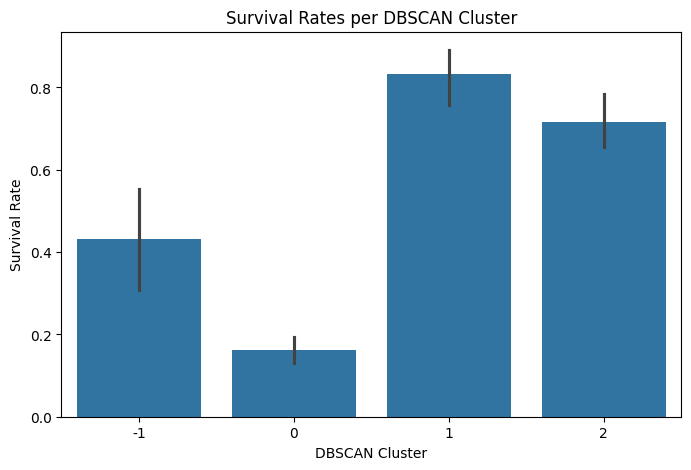

In [ ]:
# calculate DBSCAN cluster survival rates
dbscan_survival_by_cluster = df_reduced.groupby('DBScan_Cluster')['Survived'].mean()
print("\nDBSCAN Cluster Survival Rates:\n", dbscan_survival_by_cluster)

# plot DBSCAN cluster survival rates
plt.figure(figsize=(8, 5))
sns.barplot(x='DBScan_Cluster', y='Survived', data=df_reduced)
plt.title("Survival Rates per DBSCAN Cluster")
plt.xlabel('DBSCAN Cluster')
plt.ylabel('Survival Rate')
plt.show()


## Summary for DBSCAN Clusters:

*   **Cluster -1 (Noise)**: As noted, this cluster represents outliers or noise points that DBSCAN couldn't assign to a dense cluster. It's important to analyze these to understand what characteristics make them outliers. Passengers in this cluster tend to have higher fares and larger family sizes, and their survival rate is around 46.48%.

*   **Cluster 0 (Low Survival Males)**: This is the largest cluster, predominantly male (100% `Sex_male`) and largely composed of `Title_Mr` (96.19%). They have relatively low average fares and small family sizes. This cluster shows a very low survival rate of 16.00%.

*   **Cluster 1 (High Survival Married Females)**: This cluster is exclusively female (100% `Sex_female`) and entirely composed of `Title_Mrs` (100%). They have moderate average fares and family sizes. This group exhibits a very high survival rate of 83.05%.

*   **Cluster 2 (High Survival Unmarried Females)**: This cluster is also exclusively female (100% `Sex_female`), primarily consisting of `Title_Miss` (98.87%). Their characteristics regarding fare and family size are similar to Cluster 1. This cluster also shows a high survival rate of 71.75%.

***
*   **Fare and Class Distribution**: The boxplot for Fare distribution across DBSCAN clusters indicates that Clusters 1 and 2 (primarily female clusters with high survival) tend to have higher median fares and a wider spread compared to Cluster 0 (primarily male with low survival), suggesting a correlation with higher social class.

*   **Categorical Features**: The bar plot for categorical feature proportions clearly illustrates the strong segregation by gender and title across the clusters. Cluster 0 is almost entirely male (`Title_Mr`), while Clusters 1 and 2 are almost entirely female, further differentiated by `Title_Mrs` and `Title_Miss`, respectively.

This analysis highlights that DBSCAN identified meaningful clusters largely based on demographic features like gender and title, which are strongly indicative of survival outcomes on the Titanic.

**Adding Evaluation Metrics**

The metrics we will use for analysis are F1 score, precision, recall, accuracy, and ROC. We will compute these metrics for each model. We will also compare it to the baseline mentioned in our project report:

> Our baseline, based on the current data, is that approximately 38% of passengers survived, so a simple non-machine learning approach is to assign a 38% probability of survival to each individual randomly. This provides a benchmark to compare more sophisticated models. However, the dataset is imbalanced, as 62% of passengers did not survive. Thus, to account for this imbalance, we will go beyond simple accuracy as a metric and use metrics such as precision, recall, and the F1-score to ensure our model effectively identifies survivors rather than being biased toward the majority class.
For non-binary problems, such as clustering or multi-class classification, a random baseline could involve assigning data points evenly across clusters or classes without considering feature values. For example, in clustering, each data point could be randomly assigned to one of the clusters, providing a reference point to measure the added value of feature-driven clustering. This ensures that any improvement over the baseline reflects meaningful structure in the data.


In [ ]:
 # make a function for the metrics to make it easier lol
def evaluate_clustering(df, cluster_col, true_col='Survived'):
    df_eval = df.copy()

    # map each cluster to its majority class (1 = survived, 0 = died (rip))
    cluster_to_label = (
        df_eval.groupby(cluster_col)[true_col]
        .mean()
        .apply(lambda x: 1 if x >= 0.5 else 0)
        .to_dict()
    )

    # predicted labels
    y_pred = df_eval[cluster_col].map(cluster_to_label)
    y_true = df_eval[true_col]

    # metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # ROC AUC uses probabilities so we can use the cluster survival rate
    cluster_probs = df_eval.groupby(cluster_col)[true_col].mean().to_dict()
    y_prob = df_eval[cluster_col].map(cluster_probs)
    roc = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc
    }

In [ ]:
# this is for comparison with our baseline
def random_baseline_metrics(df, true_col='Survived', prob=0.38):
    y_true = df[true_col]

    # random predictions based on survival probability
    np.random.seed(42)
    y_pred = np.random.binomial(1, prob, size=len(df))

    # for ROC AUC use constant probability
    y_prob = np.full(len(df), prob)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

In [ ]:
# evaluate each model
kmeans_metrics = evaluate_clustering(df_reduced, 'KMeans_Cluster')
print("K-Means Metrics:", kmeans_metrics)

hierarchical_metrics = evaluate_clustering(df_reduced, 'Hierarchical_Cluster')
print("Hierarchical Metrics:", hierarchical_metrics)

dbscan_metrics = evaluate_clustering(df_reduced, 'DBScan_Cluster')
print("DBSCAN Metrics:", dbscan_metrics)

# baseline metrics
baseline_metrics = random_baseline_metrics(df_reduced)
print("Random Baseline:", baseline_metrics)

K-Means Metrics: {'Accuracy': 0.8092031425364759, 'Precision': 0.7654320987654321, 'Recall': 0.7251461988304093, 'F1 Score': 0.7447447447447447, 'ROC AUC': np.float64(0.8335836555566207)}
Hierarchical Metrics: {'Accuracy': 0.7901234567901234, 'Precision': 0.7170868347338936, 'Recall': 0.7485380116959064, 'F1 Score': 0.7324749642346209, 'ROC AUC': np.float64(0.7964161314031891)}
DBSCAN Metrics: {'Accuracy': 0.792368125701459, 'Precision': 0.7625418060200669, 'Recall': 0.6666666666666666, 'F1 Score': 0.7113884555382215, 'ROC AUC': np.float64(0.7996543422916733)}
Random Baseline: {'Accuracy': 0.5274971941638609, 'Precision': 0.3813813813813814, 'Recall': 0.3713450292397661, 'F1 Score': 0.3762962962962963, 'ROC AUC': np.float64(0.5)}


In [ ]:
# put it all in a clean table for easier interpreatation
metrics_df = pd.DataFrame([
    {"Model": "Random Baseline", **baseline_metrics},
    {"Model": "KMeans", **kmeans_metrics}, # y'all i totally forgot about how to do this in python omg the ** is crazy - had to ask AI how to do this
    {"Model": "Hierarchical", **hierarchical_metrics},
    {"Model": "DBSCAN", **dbscan_metrics}
])

print(metrics_df)
print()
print("KMeans Silhouette:", silhouette_score(X_scaled, df_reduced['KMeans_Cluster']))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, df_reduced['Hierarchical_Cluster']))

             Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Random Baseline  0.527497   0.381381  0.371345  0.376296  0.500000
1           KMeans  0.809203   0.765432  0.725146  0.744745  0.833584
2     Hierarchical  0.790123   0.717087  0.748538  0.732475  0.796416
3           DBSCAN  0.792368   0.762542  0.666667  0.711388  0.799654

KMeans Silhouette: 0.4470959238210298
Hierarchical Silhouette: 0.49584993567468144


**Interpretation:** As can be seen by our evaluation metrics, the baseline achieves moderate accuracy (basically has a 50/50 shot of making the correct preduction) but performs poorly on precision, recall, and F1 score. The ROC AUC is 0.5 because we are making predictions off of a random generator. On the other hand, all clustering methods significantly outperform the random guessing across every metric, indicating that survival is strongly associated with underlying feature groupings (e.g., gender, class, family structure). K-Means is the best performing model as it has the best overall balance and is best at correctly identifying survivors without too many false positives. It also had a high ROC AUC (0.83) which reinforces the classic Titanic pattern of "Women and children first" as the high-survival clusters were women in the higher classes.Hierarchical clustering has the most balanced recall, meaning that is performs the best at finding survivors. It has slightly more false positives than K-Means. DBSCAN produces tighter, more conservative clusters, leading to fewer false positives but more false negatives (so it misses more actual survivors).

The model with the best cluster separation (Hierarchical) is not the best at predicting survival meaning that better geometric clustering does not necessarily translate to better alignment with real-world outcomes like survival.

Clustering methods performing stronger than our random baseline suggests that survival on the Titanic was not random but strongly driven by structured demographic and socioeconomic factors. Among the models, K-Means achieved the best overall predicitive alignment with survival outcomes, while hierarchical clustering revealed more clear and precise clusters but with slightly worse predictive performance. DBSCAN, was more conservative and less sensitive to actually identifying survivors.


### **ALERT! ALERT! ALERT! Delete this box and anything below it before submission!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!**

**Catherine's Notes from Office hours-**

catherine note to self 4/5/26- I think I want to check with Prof. after class that the the current clusters are ok or if I should try to scale the titles down to look for secondary patterns. Also can verify that our methods are sufficient

# Also ensure someone updates the hierachical clustering interpretation.

Add more analysis and interpretation. perhaps research what happened during the titanic a bit more. Focus more on the storytelling.

We need more complex analysis. Not just male & female survival rate, but who are they?
Out of the men that survived... is the survival related to the fare?
For the fare, is there an even distribution with gender?
With the fare, is there a homogenous distribution across genders?
Make an interaction plot between men & women survival and fare.
Show why more women survived.
Look at the correlation between female with children & female without children.


Try to graph multiple features per cluster.... family size and fare size, etc. So then we can characterize stuff.

Not every cluster needs to be relevant. Pick a few important ones and describe
Are number of clusters is ok. Or we can try fewer.

Lone workers, rich couple, big families.


* Cleaning the code: Preprocessing: Maribella
* Clustering_Analysis: Catherine
* DBScan: Emmalyn
* Add three metrics per model for evaluation: Alyssa

Analysis & Interpretation
* K-means: Catherine
* DBScan: Emmalyn
* Hierarchal: Alyssa